In [ ]:
# Install required packages (run once)
!pip install networkx matplotlib numpy -q

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Some Example Codes (In Python):

=== Degree Centrality ===
Formula: C_D(v) = degree(v) / (N - 1) = degree(v) / 5

  Alice     0.600  ██████████████████  [degree=3]
  Bob       0.600  ██████████████████  [degree=3]
  Charlie   0.600  ██████████████████  [degree=3]
  You       0.400  ████████████  [degree=2]
  Eve       0.400  ████████████  [degree=2]
  David     0.200  ██████  [degree=1]


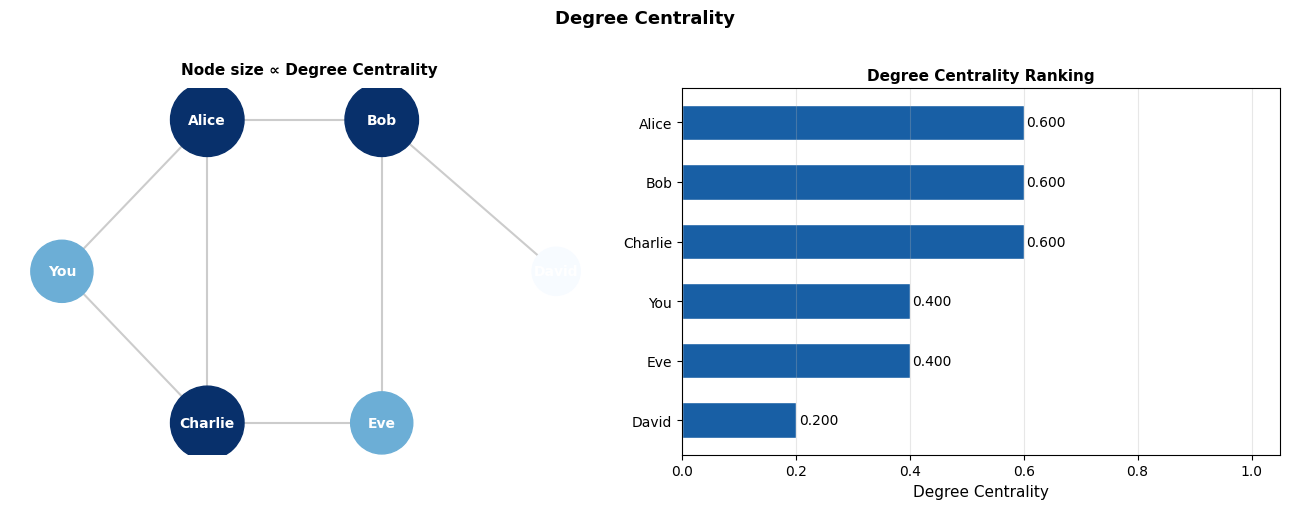

In [ ]:
# ── Degree Centrality ────────────────────────────────────────────────────────
deg_centrality = nx.degree_centrality(G)

print("=== Degree Centrality ===")
print(f"Formula: C_D(v) = degree(v) / (N - 1) = degree(v) / {G.number_of_nodes()-1}\n")
for node, score in sorted(deg_centrality.items(), key=lambda x: -x[1]):
    bar = '█' * int(score * 30)
    print(f"  {node:8s}  {score:.3f}  {bar}  [degree={G.degree(node)}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph with node size ∝ degree centrality
sizes = [deg_centrality[n] * 4000 + 400 for n in G.nodes()]
colors = [deg_centrality[n] for n in G.nodes()]
nx.draw_networkx(
    G, pos, ax=axes[0],
    node_size=sizes, node_color=colors, cmap='Blues',
    font_color='white', font_weight='bold', font_size=10,
    edge_color='#cccccc', width=1.5,
)
axes[0].set_title('Node size ∝ Degree Centrality', fontsize=11, fontweight='bold', pad=10)
axes[0].axis('off')

# Right: bar chart
sorted_nodes = sorted(deg_centrality, key=deg_centrality.get, reverse=True)
axes[1].barh(
    sorted_nodes,
    [deg_centrality[n] for n in sorted_nodes],
    color='#185FA5', edgecolor='white', height=0.6
)
for i, node in enumerate(sorted_nodes):
    v = deg_centrality[node]
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
axes[1].set_xlabel('Degree Centrality', fontsize=11)
axes[1].set_title('Degree Centrality Ranking', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Degree Centrality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Shortest paths from Alice to all others ===
  Alice → You     : 1 hop(s)
  Alice → Bob     : 1 hop(s)
  Alice → Charlie : 1 hop(s)
  Alice → David   : 2 hop(s)
  Alice → Eve     : 2 hop(s)

  Sum of distances = 7
  Closeness(Alice) = (N-1) / sum = 5/7 = 0.714

=== All Closeness Centralities ===
  Alice     0.714  █████████████████████
  Bob       0.714  █████████████████████
  Charlie   0.625  ██████████████████
  Eve       0.625  ██████████████████
  You       0.556  ████████████████
  David     0.455  █████████████


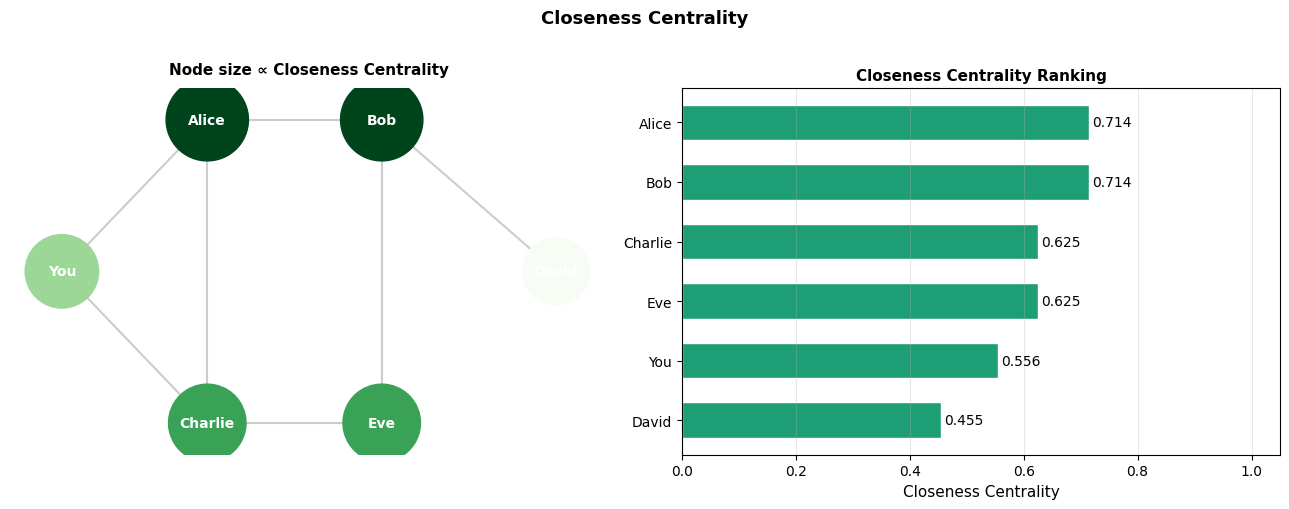

In [ ]:
# ── Closeness Centrality ─────────────────────────────────────────────────────
close_centrality = nx.closeness_centrality(G)

# Show the shortest path distances from Alice to understand the formula
print("=== Shortest paths from Alice to all others ===")
lengths = nx.single_source_shortest_path_length(G, 'Alice')
total_dist = sum(v for k, v in lengths.items() if k != 'Alice')
alice_closeness = (G.number_of_nodes() - 1) / total_dist
for target, dist in lengths.items():
    if target != 'Alice':
        print(f"  Alice → {target:8s}: {dist} hop(s)")
print(f"\n  Sum of distances = {total_dist}")
print(f"  Closeness(Alice) = (N-1) / sum = {G.number_of_nodes()-1}/{total_dist} = {alice_closeness:.3f}")

print("\n=== All Closeness Centralities ===")
for node, score in sorted(close_centrality.items(), key=lambda x: -x[1]):
    bar = '█' * int(score * 30)
    print(f"  {node:8s}  {score:.3f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph
sizes = [close_centrality[n] * 4500 + 300 for n in G.nodes()]
colors = [close_centrality[n] for n in G.nodes()]
nx.draw_networkx(
    G, pos, ax=axes[0],
    node_size=sizes, node_color=colors, cmap='Greens',
    font_color='white', font_weight='bold', font_size=10,
    edge_color='#cccccc', width=1.5,
)
axes[0].set_title('Node size ∝ Closeness Centrality', fontsize=11, fontweight='bold', pad=10)
axes[0].axis('off')

# Right: bar chart
sorted_nodes = sorted(close_centrality, key=close_centrality.get, reverse=True)
axes[1].barh(
    sorted_nodes,
    [close_centrality[n] for n in sorted_nodes],
    color='#1D9E75', edgecolor='white', height=0.6
)
for i, node in enumerate(sorted_nodes):
    v = close_centrality[node]
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
axes[1].set_xlabel('Closeness Centrality', fontsize=11)
axes[1].set_title('Closeness Centrality Ranking', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Closeness Centrality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Paths that pass through Alice ===
  You → Alice → Bob
  You → Alice → Bob → David
  Bob → Alice → You
  Bob → Alice → Charlie
  Charlie → Alice → Bob
  Charlie → Alice → Bob → David
  David → Bob → Alice → You
  David → Bob → Alice → Charlie

=== All Betweenness Centralities ===
  Bob       0.450  ███████████████████████████
  Alice     0.300  ██████████████████
  Charlie   0.150  █████████
  Eve       0.100  ██████
  You       0.000  
  David     0.000  


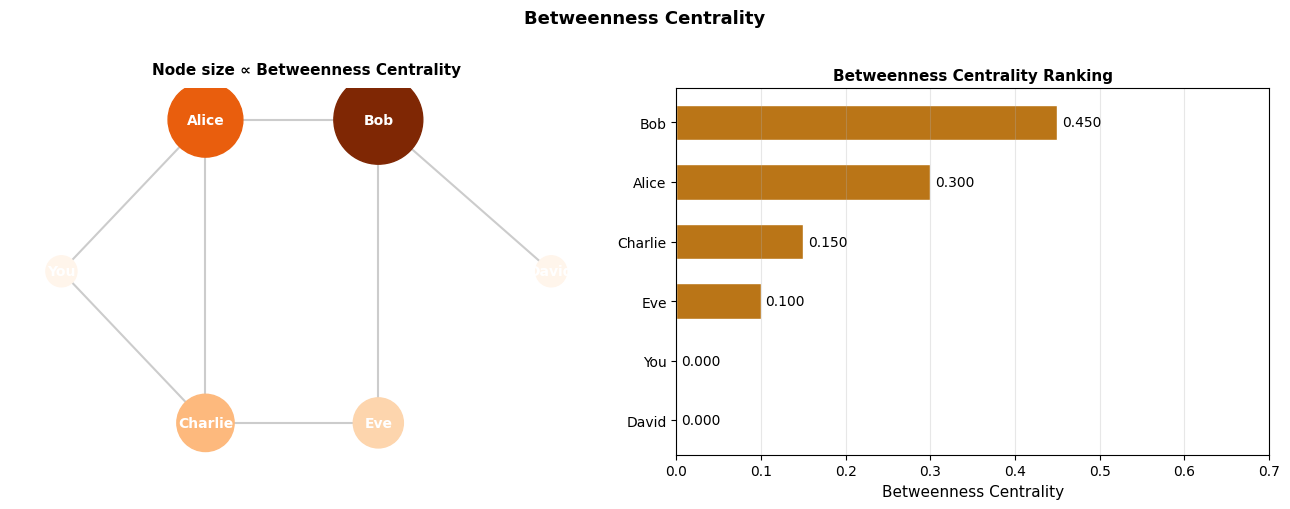

In [ ]:
# ── Betweenness Centrality ───────────────────────────────────────────────────
betw_centrality = nx.betweenness_centrality(G, normalized=True)

# Manually show which paths pass through Alice
print("=== Paths that pass through Alice ===")
all_pairs = list(nx.all_pairs_shortest_path(G))
through_alice = []
for src, paths in all_pairs:
    for dst, path in paths.items():
        if src != dst and 'Alice' in path[1:-1]:   # middle of path
            through_alice.append(f"{src} → {' → '.join(path[1:])}")
for p in through_alice:
    print(f"  {p}")

print("\n=== All Betweenness Centralities ===")
for node, score in sorted(betw_centrality.items(), key=lambda x: -x[1]):
    bar = '█' * int(score * 60)
    print(f"  {node:8s}  {score:.3f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph, highlight high-betweenness nodes
sizes  = [betw_centrality[n] * 8000 + 500 for n in G.nodes()]
colors = [betw_centrality[n] for n in G.nodes()]
nx.draw_networkx(
    G, pos, ax=axes[0],
    node_size=sizes, node_color=colors, cmap='Oranges',
    font_color='white', font_weight='bold', font_size=10,
    edge_color='#cccccc', width=1.5,
)
axes[0].set_title('Node size ∝ Betweenness Centrality', fontsize=11, fontweight='bold', pad=10)
axes[0].axis('off')

# Right: bar chart
sorted_nodes = sorted(betw_centrality, key=betw_centrality.get, reverse=True)
axes[1].barh(
    sorted_nodes,
    [betw_centrality[n] for n in sorted_nodes],
    color='#BA7517', edgecolor='white', height=0.6
)
for i, node in enumerate(sorted_nodes):
    v = betw_centrality[node]
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
axes[1].set_xlabel('Betweenness Centrality', fontsize=11)
axes[1].set_title('Betweenness Centrality Ranking', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 0.7)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Betweenness Centrality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Centrality Comparison Table ===
         Degree  Closeness  Betweenness
Node                                   
Bob         0.6      0.714         0.45
Alice       0.6      0.714         0.30
Charlie     0.6      0.625         0.15
Eve         0.4      0.625         0.10
You         0.4      0.556         0.00
David       0.2      0.455         0.00


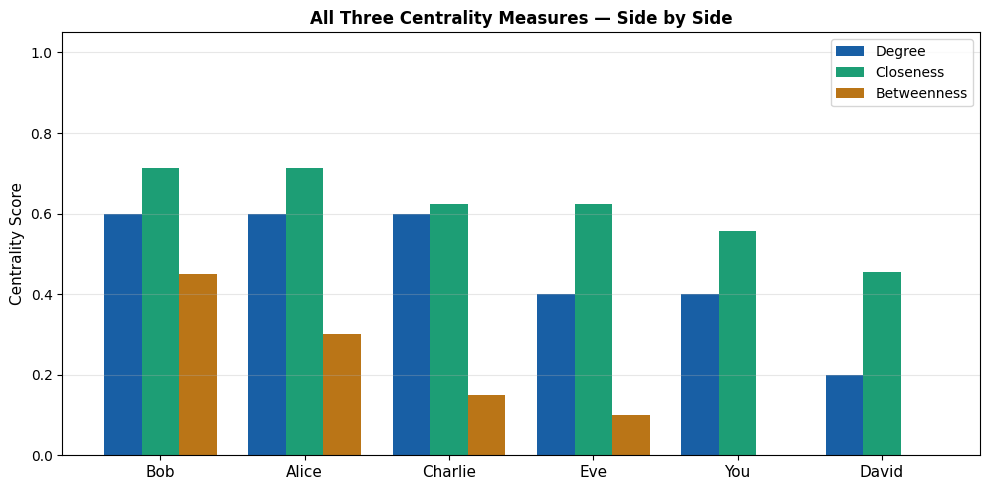


=== Key Takeaways ===
  Most connected (Degree)     : Alice
  Fastest to reach all (Close): Alice
  Biggest bridge (Between)    : Bob


In [ ]:
### Centrality Comparison: All Three Measures

# ── Side-by-side comparison of all three centralities ──────────────────────
df_centrality = pd.DataFrame({
    'Degree':      deg_centrality,
    'Closeness':   close_centrality,
    'Betweenness': betw_centrality,
}).round(3)
df_centrality.index.name = 'Node'
print("=== Centrality Comparison Table ===")
print(df_centrality.sort_values('Betweenness', ascending=False).to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(node_list))
w = 0.26
nodes_sorted = df_centrality.sort_values('Betweenness', ascending=False).index.tolist()

ax.bar(x - w, [df_centrality.loc[n,'Degree']      for n in nodes_sorted], w, label='Degree',      color='#185FA5')
ax.bar(x,     [df_centrality.loc[n,'Closeness']   for n in nodes_sorted], w, label='Closeness',   color='#1D9E75')
ax.bar(x + w, [df_centrality.loc[n,'Betweenness'] for n in nodes_sorted], w, label='Betweenness', color='#BA7517')

ax.set_xticks(x)
ax.set_xticklabels(nodes_sorted, fontsize=11)
ax.set_ylabel('Centrality Score', fontsize=11)
ax.set_title('All Three Centrality Measures — Side by Side', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Key Takeaways ===")
print(f"  Most connected (Degree)     : {max(deg_centrality,   key=deg_centrality.get)}")
print(f"  Fastest to reach all (Close): {max(close_centrality, key=close_centrality.get)}")
print(f"  Biggest bridge (Between)    : {max(betw_centrality,  key=betw_centrality.get)}")